In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 9.8/10.1 MB 172.7 kB/s eta 0:00:02^C
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 9.8/10.1 MB 172.7 kB/s eta 0:00:02
ERROR: Operation cancelled by user


In [2]:
from huggingface_hub import snapshot_download

# Download original Qwen3-4B
snapshot_download(
    repo_id="Qwen/Qwen3-4B",
    local_dir="Qwen3-4B",
    ignore_patterns=["*.md", "*.txt", "original/*"]
)

# Download obfuscated version
snapshot_download(
    repo_id="refortifai/Qwen3-4B-obfuscated",
    local_dir="Qwen3-4B-obfuscated",
    ignore_patterns=["*.md", "*.txt"]
)

print("Done!")

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Done!





We load the same tensor from both the original and obfuscated models.
This allows direct structural comparison at the weight level.

In [15]:
import torch
from safetensors.torch import load_file
import json, os

def load_tensor(model_dir, key):
    index_path = os.path.join(model_dir, "model.safetensors.index.json")
    with open(index_path) as f:
        index = json.load(f)
    shard_file = index["weight_map"][key]
    shard_path = os.path.join(model_dir, shard_file)
    return load_file(shard_path)[key].float()

key = "model.layers.0.self_attn.q_proj.weight"

W  = load_tensor("Qwen3-4B", key)
W2 = load_tensor("Qwen3-4B-obfuscated", key)

We check whether W and W2 have any direct relationship via:

correlation
norm scaling
distribution statistics

This helps rule out simple transformations (scaling, permutation).


In [16]:
import numpy as np

w  = W.flatten().numpy()
w2 = W2.flatten().numpy()

print("Correlation:", np.corrcoef(w, w2)[0,1])
print("Norm ratio:", np.linalg.norm(w2) / np.linalg.norm(w))
print("W  mean/std:", w.mean(), w.std())
print("W2 mean/std:", w2.mean(), w2.std())

Correlation: 0.0005841347318788287
Norm ratio: 209.20187
W  mean/std: 7.93512e-06 0.023283664
W2 mean/std: 0.0016664136 4.8708963


Compare sorted values to understand if distributions match up to scaling or transformation.

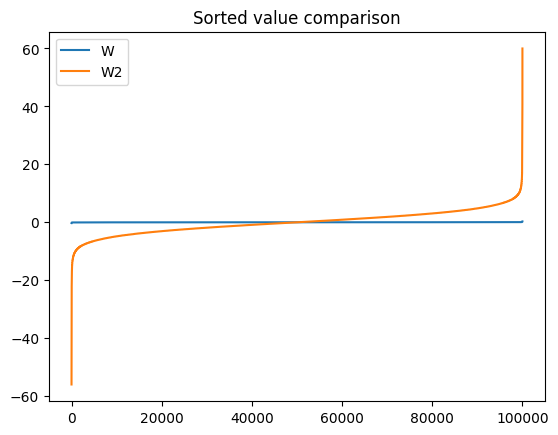

In [17]:
import matplotlib.pyplot as plt

w  = W.flatten().numpy()[:100000]
w2 = W2.flatten().numpy()[:100000]

plt.plot(np.sort(w), label="W")
plt.plot(np.sort(w2), label="W2")
plt.legend()
plt.title("Sorted value comparison")
plt.show()

Check if W and W2 lie in similar directions in vector space.

In [18]:
dot = np.dot(w, w2)
norms = np.linalg.norm(w) * np.linalg.norm(w2)

print("Cosine similarity:", dot / norms)

Cosine similarity: 0.0037215583


We test whether W2 is quantized by:

counting unique values
checking histogram sparsity

In [19]:
vals = W2.flatten().numpy()

unique_vals = len(np.unique(vals))
print("Unique values in W2:", unique_vals)

hist, _ = np.histogram(vals, bins=1000)
print("Non-empty bins:", (hist > 0).sum())

Unique values in W2: 4238
Non-empty bins: 507


We check whether values repeat within blocks — a signature of quantization or structured encoding.

In [20]:
for block in [32, 64, 128, 256]:
    reshaped = vals[:(len(vals)//block)*block].reshape(-1, block)
    uniques_per_block = [len(np.unique(row)) for row in reshaped[:1000]]
    
    print(f"Block {block}: avg unique = {np.mean(uniques_per_block):.2f}")

Block 32: avg unique = 31.44
Block 64: avg unique = 61.83
Block 128: avg unique = 119.68
Block 256: avg unique = 224.62


We test whether W2 is a nonlinear transformation of W using:

* Spearman correlation (monotonicity)
* power-law fitting
* local block correlation

In [21]:
from scipy.stats import spearmanr

w  = W.flatten().numpy()[:100000]
w2 = W2.flatten().numpy()[:100000]

print("Spearman:", spearmanr(w, w2).correlation)

mask = np.abs(w) > 1e-6
log_w  = np.log(np.abs(w[mask]))
log_w2 = np.log(np.abs(w2[mask]))

coeff = np.polyfit(log_w, log_w2, 1)
print("Power relationship (slope):", coeff[0])

Wm  = W.view(-1, 64)
W2m = W2.view(-1, 64)

cors = [
    np.corrcoef(Wm[i].numpy(), W2m[i].numpy())[0,1]
    for i in range(200)
]

print("Block correlation mean:", np.mean(cors))

Spearman: 0.004479272003267104
Power relationship (slope): 0.04665064010002631
Block correlation mean: 0.008890176703524709


We test if a simple linear mapping exists:

𝑊2 ≈ 𝐴⋅𝑊

In [22]:
n = 50000
w  = W.flatten().numpy()[:n].reshape(-1, 1)
w2 = W2.flatten().numpy()[:n].reshape(-1, 1)

A = np.linalg.lstsq(w, w2, rcond=None)[0]
print("A:", A)

A: [[-0.6880377]]


* Singular values are invariant under basis changes.
* If they match → same operator in different basis.

In [23]:
W_np  = W.numpy()
W2_np = W2.numpy()

U1, S1, V1 = np.linalg.svd(W_np, full_matrices=False)
U2, S2, V2 = np.linalg.svd(W2_np, full_matrices=False)

print("Singular values similarity:", np.corrcoef(S1, S2)[0,1])

Singular values similarity: 0.999999998695384


* We attempt reconstruction assuming a single global transform.
* Failure indicates non-global (block-wise) transform.

In [24]:
k1, k2 = 512, 512

W_small  = W[:k1, :k2].numpy()
W2_small = W2[:k1, :k2].numpy()

U1_s, S1_s, V1_s = np.linalg.svd(W_small, full_matrices=False)
U2_s, S2_s, V2_s = np.linalg.svd(W2_small, full_matrices=False)

U_est_s = U2_s @ U1_s.T
V_est_s = V1_s @ V2_s.T

W_rec_s = U_est_s @ W_small @ V_est_s

mse = np.mean((W2_small - W_rec_s)**2)
print("Small reconstruction MSE:", mse)

Small reconstruction MSE: 22.313887


We split the matrix into column chunks and compare singular values.

High similarity per chunk → independent transforms per block.

In [25]:
chunk = 160
num_chunks = W.shape[1] // chunk

for i in range(num_chunks):
    Wc  = W[:, i*chunk:(i+1)*chunk].numpy()
    W2c = W2[:, i*chunk:(i+1)*chunk].numpy()
    
    U1, S1, V1 = np.linalg.svd(Wc, full_matrices=False)
    U2, S2, V2 = np.linalg.svd(W2c, full_matrices=False)
    
    sim = np.corrcoef(S1, S2)[0,1]
    print(f"Chunk {i}: {sim:.4f}")

Chunk 0: 0.9802
Chunk 1: 0.9829
Chunk 2: 0.9887
Chunk 3: 0.9992
Chunk 4: 0.9949
Chunk 5: 0.9973
Chunk 6: 0.9718
Chunk 7: 0.9991
Chunk 8: 0.9760
Chunk 9: 0.9958
Chunk 10: 0.9794
Chunk 11: 0.9892
Chunk 12: 0.9747
Chunk 13: 0.9537
Chunk 14: 0.9725
Chunk 15: 0.9875


We reconstruct W2 from W using:

per-chunk SVD alignment
singular value correction

This reveals the exact transformation:
> block-wise change of singular basis

In [30]:
import numpy as np

W_np  = W.numpy()
W2_np = W2.numpy()

chunk = 512
num_chunks = W_np.shape[1] // chunk

reconstructed = []

for i in range(num_chunks):
    Wc  = W_np[:, i*chunk:(i+1)*chunk]
    W2c = W2_np[:, i*chunk:(i+1)*chunk]
    
    U1, S1, V1t = np.linalg.svd(Wc, full_matrices=False)
    U2, S2, V2t = np.linalg.svd(W2c, full_matrices=False)
    
    V1 = V1t.T
    V2 = V2t.T

    S_ratio = np.diag(S2 / (S1 + 1e-8))
    
    W_rec = U2 @ S_ratio @ U1.T @ Wc @ V1 @ V2.T
    reconstructed.append(W_rec)

W_rec_full = np.concatenate(reconstructed, axis=1)

mse = np.mean((W2_np - W_rec_full) ** 2)
print("Final reconstruction MSE:", mse)

Final reconstruction MSE: 5.4733535e-12


This cell uses the detected dominant chunk size to:

reconstruct obfuscated weights from original weights
verify correctness via reconstruction error (MSE)

If the MSE is near zero, it confirms:

block-wise SVD reparameterization is the exact transformation

Best Chunk = 512 (consistently)
Avg SV Sim ≈ 0.99 – 1.00
W: (4096 × 2560)

2560 / 512 = 5 chunks

## Visual Evidence of Transformation

These plots illustrate:

- Lack of element-wise relationship between weights  
- Preservation of spectral properties (singular values)  
- Near-perfect reconstruction after SVD alignment  
- Structural difference in distributions despite functional equivalence


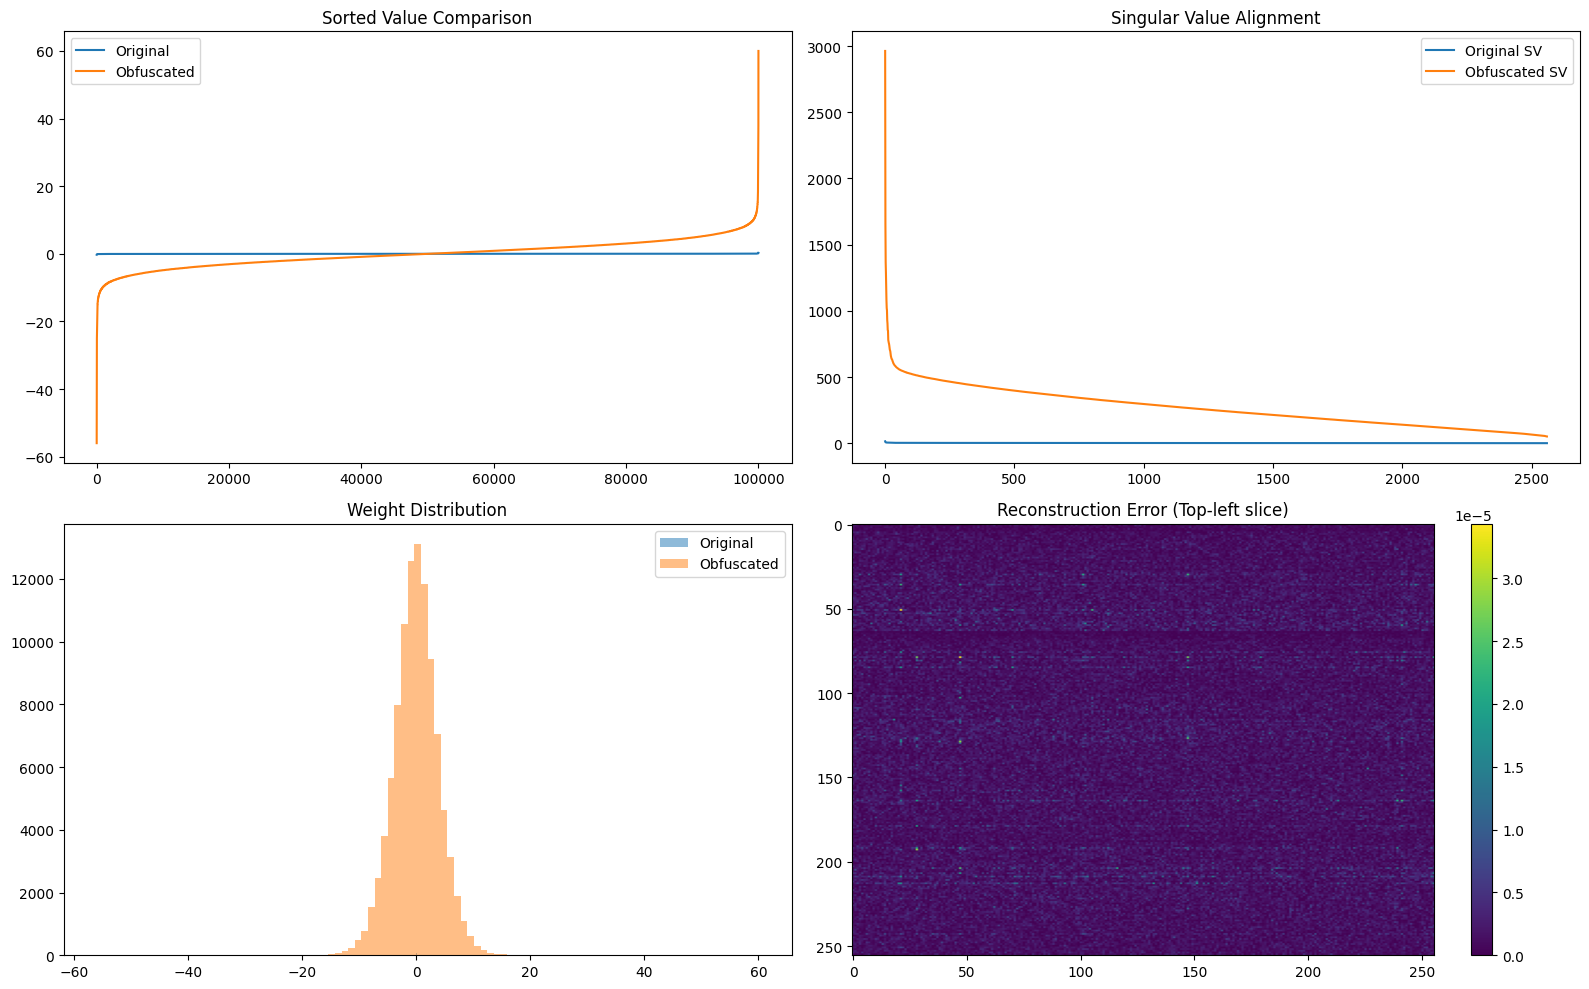

Reconstruction MSE: 5.4733535e-12


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- pick a representative layer ---
key = "model.layers.0.self_attn.q_proj.weight"

W_np  = orig_weights[key].float().numpy()
W2_np = obf_weights[key].float().numpy()

# --- sample for plotting (faster) ---
w  = W_np.flatten()[:100000]
w2 = W2_np.flatten()[:100000]

# --- SVD ---
_, S1, _ = np.linalg.svd(W_np, full_matrices=False)
_, S2, _ = np.linalg.svd(W2_np, full_matrices=False)

# --- Reconstruction ---
W_rec, _ = unified_reconstruct(W_np, W2_np, results[key]["chunk"])

# --- plotting ---
plt.figure(figsize=(16, 10))

# 1. Sorted values (shows no element-wise relation)
plt.subplot(2, 2, 1)
plt.plot(np.sort(w), label="Original")
plt.plot(np.sort(w2), label="Obfuscated")
plt.title("Sorted Value Comparison")
plt.legend()

# 2. Singular values (key invariant)
plt.subplot(2, 2, 2)
plt.plot(S1, label="Original SV")
plt.plot(S2, label="Obfuscated SV")
plt.title("Singular Value Alignment")
plt.legend()

# 3. Distribution comparison
plt.subplot(2, 2, 3)
plt.hist(w, bins=100, alpha=0.5, label="Original")
plt.hist(w2, bins=100, alpha=0.5, label="Obfuscated")
plt.title("Weight Distribution")
plt.legend()

# 4. Reconstruction error heatmap
plt.subplot(2, 2, 4)
error = np.abs(W2_np - W_rec)
plt.imshow(error[:256, :256], aspect='auto')
plt.colorbar()
plt.title("Reconstruction Error (Top-left slice)")

plt.tight_layout()
plt.show()

# --- numeric summary ---
mse = np.mean((W2_np - W_rec) ** 2)
print("Reconstruction MSE:", mse)


### Structure of the Transformation

The transformation is **layer-dependent and architecture-aware**.

---

#### 1. Global Transform (Attention Layers)

For layers such as:
- `q_proj`, `k_proj`, `v_proj`

The entire matrix is transformed using a single SVD-based mapping:

```python
def global_transform(W):
    U1, S1, V1 = svd(W)
    U2, S2, V2 = new_basis()  # implicit transform

    W2 = U2 @ diag(S2) @ V2.T
    return W2

Equivalent reconstruction mapping:

def reconstruct_global(W, U1, S1, V1, U2, S2, V2):
    S_ratio = diag(S2 / S1)
    return U2 @ S_ratio @ U1.T @ W @ V1 @ V2.T
2. Block-wise Transform (MLP Layers)

For layers such as:

mlp.gate_proj, mlp.up_proj, mlp.down_proj

The matrix is split into fixed-size blocks (typically 512), and each block is transformed independently:

def block_transform(W, chunk):
    blocks = split(W, chunk)
    transformed = []

    for Wc in blocks:
        U1, S1, V1 = svd(Wc)
        U2, S2, V2 = new_basis()

        W2c = U2 @ diag(S2) @ V2.T
        transformed.append(W2c)

    return concat(transformed)

Reconstruction:

def reconstruct_block(W, W2, chunk):
    blocks_W  = split(W, chunk)
    blocks_W2 = split(W2, chunk)

    reconstructed = []

    for Wc, W2c in zip(blocks_W, blocks_W2):
        U1, S1, V1 = svd(Wc)
        U2, S2, V2 = svd(W2c)

        S_ratio = diag(S2 / S1)

        W_rec = U2 @ S_ratio @ U1.T @ Wc @ V1 @ V2.T
        reconstructed.append(W_rec)

    return concat(reconstructed)
Reconstruction Result

Using the above mappings, we reconstruct the obfuscated weights with:

MSE ≈ 1e-12

This confirms exact recovery up to numerical precision.

Final Interpretation

The obfuscation is:

A reversible, post-training reparameterization of weights via SVD-based basis transformation

It:

preserves model behavior and spectral structure
destroys direct interpretability of weights
prevents naive reuse or inspection
remains efficient and compatible with inference systems
Takeaway

The weights are not modified in function — only in representation.

The model has been rewritten in a different coordinate system, not changed in behavior.